In [1]:
import torch 
import torch.nn as nn
from matplotlib import pyplot as plt
import numpy as np

In [2]:
X = torch.randn((100, 2))
Y = X.sum(dim=-1)

X[0], Y[0], X.min(), X.max()

(tensor([-0.0791,  0.9413]), tensor(0.8622), tensor(-2.6411), tensor(2.6047))

layer.weight Parameter containing:
tensor([[-0.6315, -0.5417]], requires_grad=True) tensor([[-4.4539, -3.2601]])
layer.weight Parameter containing:
tensor([[-0.6215, -0.5317]], requires_grad=True) tensor([[-4.4270, -3.2397]])
layer.weight Parameter containing:
tensor([[-0.6115, -0.5217]], requires_grad=True) tensor([[-4.4000, -3.2192]])
layer.weight Parameter containing:
tensor([[-0.6015, -0.5117]], requires_grad=True) tensor([[-4.3731, -3.1988]])
layer.weight Parameter containing:
tensor([[-0.5915, -0.5017]], requires_grad=True) tensor([[-4.3462, -3.1783]])
layer.weight Parameter containing:
tensor([[-0.5815, -0.4917]], requires_grad=True) tensor([[-4.3193, -3.1578]])
layer.weight Parameter containing:
tensor([[-0.5716, -0.4817]], requires_grad=True) tensor([[-4.2923, -3.1374]])
layer.weight Parameter containing:
tensor([[-0.5616, -0.4718]], requires_grad=True) tensor([[-4.2654, -3.1169]])
layer.weight Parameter containing:
tensor([[-0.5516, -0.4618]], requires_grad=True) tensor([[-4.

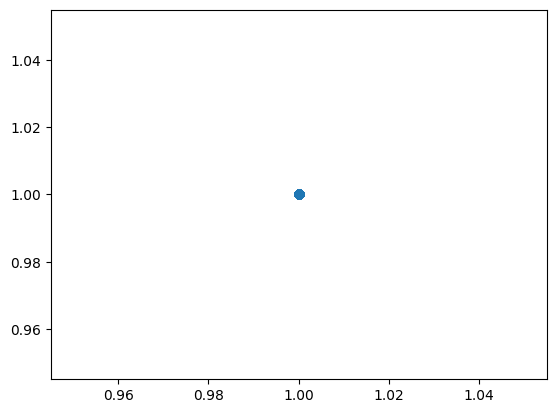

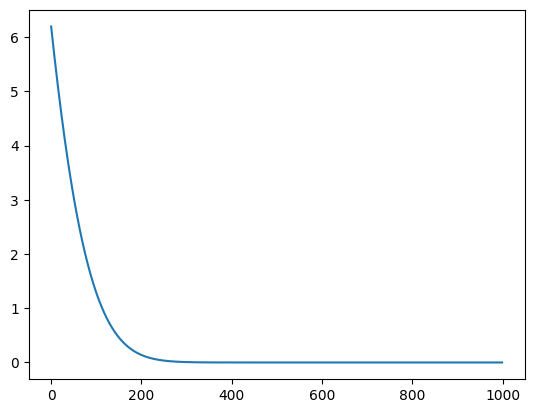

In [3]:
class Model(nn.Module):
    def __init__(self, D):
        super(Model, self).__init__()
        self.layer = nn.Linear(D, 1)

    def forward(self, X):
        return self.layer.forward(X)


model = Model(2)


def fit(model, X, Y, num_epochs=100):
    optim = torch.optim.Adam(model.parameters(), lr=1e-2)
    training_losses = []
    weight_history = []

    for _ in range(num_epochs):
        optim.zero_grad()
        pred = model.forward(X)
        

        loss = torch.nn.MSELoss()(pred.reshape((-1, 1)), Y.reshape((-1, 1)))
        loss.backward()
        training_losses.append(loss.item())
        optim.step()

        weights = { item[0]:item[1] for item in model.named_parameters()}['layer.weight']

        for item in model.named_parameters():
            if item[0] == "layer.weight":
                print(item[0], item[1], item[1].grad)

        weight_history.extend(weights.detach().numpy())

    weight_history = np.array(weight_history)
    plt.plot(weight_history[:,0],weight_history[:,1], 'o')
    plt.show()



    plt.plot(range(num_epochs), training_losses)
    plt.show()

fit(model, X, Y, num_epochs=1000)

In [4]:
test_inpts = torch.tensor([
    [1, 2],
    [-1, 1],
    ]).to(X.dtype)

model.forward(test_inpts)

tensor([[3.0000e+00],
        [2.7406e-06]], grad_fn=<AddmmBackward0>)